In [1]:
import pandas as pd
import numpy as np 

In [2]:
df = pd.read_csv("fraud_transaction_output_lightgbm.csv")
df.head()

,User,Merchant Name,Year,Month,Day,Time,is_new_merchant_for_user,is_new_mcc_for_user,tx_count_24h,time_since_prev_tx,amount_vs_user_median,Is Fraud?,fraud_score,fraud_band,fraud_action
0,0,1913477460590765860,2017,5,15,06:19,0,1,3.0,73740.0,2.262394,0,0.001149,Medium,Monitor
1,0,-34551508091458520,2017,5,15,06:38,0,1,2.0,1140.0,1.197183,0,0.001175,Low,Approve
2,0,-86825621511712373,2017,5,15,10:49,0,1,3.0,15060.0,0.369499,0,0.001060,High,OTP
3,0,-727612092139916043,2017,5,16,06:30,0,1,3.0,70860.0,0.532535,0,0.001044,Critical,Decline
4,0,4060646732831064559,2017,5,18,06:17,0,0,3.0,172020.0,1.772817,0,0.001130,Medium,Monitor


In [3]:
print(df.shape)
print(df["fraud_band"].value_counts())

(4877375, 15)
fraud_band
Critical    1506366
High        1261561
Low         1208798
Medium       900650
Name: count, dtype: int64


In [4]:
# -------------------------------
# GNN DEMO DATASET CREATION
# -------------------------------

GNN_SAMPLE_SIZE = 3000   # safe for MacBook demo
RANDOM_STATE = 42

gnn_demo_df = (
    df
    .query("fraud_band in ['High', 'Critical']")
    .sample(
        n=min(GNN_SAMPLE_SIZE, len(df.query("fraud_band in ['High', 'Critical']"))),
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)

print("GNN demo shape:", gnn_demo_df.shape)

GNN demo shape: (3000, 15)


In [5]:
gnn_columns = [
    # --- Features ---
    "is_new_merchant_for_user",
    "is_new_mcc_for_user",
    "tx_count_24h",
    "time_since_prev_tx",
    "amount_vs_user_median",
    "fraud_score",

    # --- Labels / metadata ---
    "Is Fraud?",
    "fraud_band",
    "fraud_action"
]

gnn_demo_df = gnn_demo_df[gnn_columns]

In [6]:
float_cols = [
    "tx_count_24h",
    "time_since_prev_tx",
    "amount_vs_user_median",
    "fraud_score"
]

binary_cols = [
    "is_new_merchant_for_user",
    "is_new_mcc_for_user",
    "Is Fraud?"
]

gnn_demo_df[float_cols] = gnn_demo_df[float_cols].astype("float32")
gnn_demo_df[binary_cols] = gnn_demo_df[binary_cols].astype("int8")

In [7]:
gnn_demo_df.to_csv("gnn_demo_transactions.csv", index=False)
print("Saved gnn_demo_transactions.csv")

Saved gnn_demo_transactions.csv


In [8]:
df1 = pd.read_csv("gnn_demo_transactions.csv")
df1.head()

,is_new_merchant_for_user,is_new_mcc_for_user,tx_count_24h,time_since_prev_tx,amount_vs_user_median,fraud_score,Is Fraud?,fraud_band,fraud_action
0,0,1,6.0,70260.0,0.052176,0.001044,0,Critical,Decline
1,0,0,9.0,240.0,-1.510311,0.001057,0,High,OTP
2,0,1,4.0,23640.0,1.031966,0.001044,0,Critical,Decline
3,0,1,1.0,14700.0,0.719481,0.001067,0,High,OTP
4,0,1,3.0,42360.0,0.929801,0.001044,0,Critical,Decline


In [9]:
df1.shape

(3000, 9)

In [10]:
print(df1.shape)
print(df1["fraud_band"].value_counts())
df1.head()

(3000, 9)
fraud_band
Critical    1641
High        1359
Name: count, dtype: int64


,is_new_merchant_for_user,is_new_mcc_for_user,tx_count_24h,time_since_prev_tx,amount_vs_user_median,fraud_score,Is Fraud?,fraud_band,fraud_action
0,0,1,6.0,70260.0,0.052176,0.001044,0,Critical,Decline
1,0,0,9.0,240.0,-1.510311,0.001057,0,High,OTP
2,0,1,4.0,23640.0,1.031966,0.001044,0,Critical,Decline
3,0,1,1.0,14700.0,0.719481,0.001067,0,High,OTP
4,0,1,3.0,42360.0,0.929801,0.001044,0,Critical,Decline


In [11]:
import torch
import numpy as np
from torch_geometric.data import Data

tx_features = [
    "is_new_merchant_for_user",
    "is_new_mcc_for_user",
    "tx_count_24h",
    "time_since_prev_tx",
    "amount_vs_user_median",
    "fraud_score"
]

X = torch.tensor(
    df1[tx_features].values,
    dtype=torch.float32
)

y = torch.tensor(
    df1["Is Fraud?"].values,
    dtype=torch.float32
)

In [12]:
edges = []
MAX_NEIGHBORS = 2

for band, g in df1.groupby("fraud_band"):
    idx = g.index.to_list()
    for i in range(len(idx)):
        for j in range(i+1, min(i+1+MAX_NEIGHBORS, len(idx))):
            edges.append([idx[i], idx[j]])
            edges.append([idx[j], idx[i]])

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

print("Nodes:", X.shape[0])
print("Edges:", edge_index.shape[1])

Nodes: 3000
Edges: 11988


In [13]:
data = Data(
    x=X,
    edge_index=edge_index,
    y=y
)

print(data)

Data(x=[3000, 6], edge_index=[2, 11988], y=[3000])


In [14]:
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class DemoFraudGNN(torch.nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.conv = SAGEConv(in_dim, 16)
        self.out = torch.nn.Linear(16, 1)

    def forward(self, data):
        x = F.relu(self.conv(data.x, data.edge_index))
        return self.out(x).squeeze()

model = DemoFraudGNN(data.x.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [15]:
for epoch in range(5):
    optimizer.zero_grad()

    logits = model(data)
    loss = F.binary_cross_entropy_with_logits(
        logits, data.y
    )

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

Epoch 0 | Loss: 985.1487
Epoch 1 | Loss: 143.6518
Epoch 2 | Loss: 1.3838
Epoch 3 | Loss: 2.1901
Epoch 4 | Loss: 2.9079


In [17]:
pos = df1["Is Fraud?"].sum()
neg = len(df1) - pos
pos_weight = torch.tensor([neg / pos], dtype=torch.float32)

optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

for epoch in range(8):
    model.train()
    optimizer.zero_grad()

    logits = model(data)

    loss = F.binary_cross_entropy_with_logits(
        logits,
        data.y,
        pos_weight=pos_weight
    )

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

Epoch 0 | Loss: 5279.4902
Epoch 1 | Loss: 4700.9482
Epoch 2 | Loss: 4126.7656
Epoch 3 | Loss: 3556.9944
Epoch 4 | Loss: 2991.6106
Epoch 5 | Loss: 2468.4724
Epoch 6 | Loss: 1960.0958
Epoch 7 | Loss: 1458.3475


In [18]:
model.eval()
with torch.no_grad():
    df1["gnn_score"] = torch.sigmoid(model(data)).numpy()

df1[["fraud_score", "gnn_score", "fraud_band"]].head()

,fraud_score,gnn_score,fraud_band
0,0.001044,0.0,Critical
1,0.001057,0.0,High
2,0.001044,0.0,Critical
3,0.001067,1.0,High
4,0.001044,0.0,Critical


In [19]:
import numpy as np

# Take top risky nodes by GNN score
top_nodes = (
    df1
    .sort_values("gnn_score", ascending=False)
    .head(30)
    .index
    .tolist()
)

top_nodes

[1604,
 1827,
 331,
 1822,
 2386,
 1350,
 2720,
 712,
 2722,
 1052,
 318,
 716,
 2729,
 310,
 2092,
 2735,
 726,
 1369,
 2372,
 293,
 2745,
 707,
 1057,
 182,
 2079,
 679,
 2673,
 1855,
 2678,
 1076]

In [20]:
import networkx as nx

G = nx.Graph()

for band, g in df1.loc[top_nodes].groupby("fraud_band"):
    idx = g.index.tolist()
    for i in range(len(idx)):
        for j in range(i + 1, len(idx)):
            G.add_edge(idx[i], idx[j])

In [21]:
for node in G.nodes():
    G.nodes[node]["gnn_score"] = df1.loc[node, "gnn_score"]
    G.nodes[node]["fraud_score"] = df1.loc[node, "fraud_score"]
    G.nodes[node]["fraud_band"] = df1.loc[node, "fraud_band"]

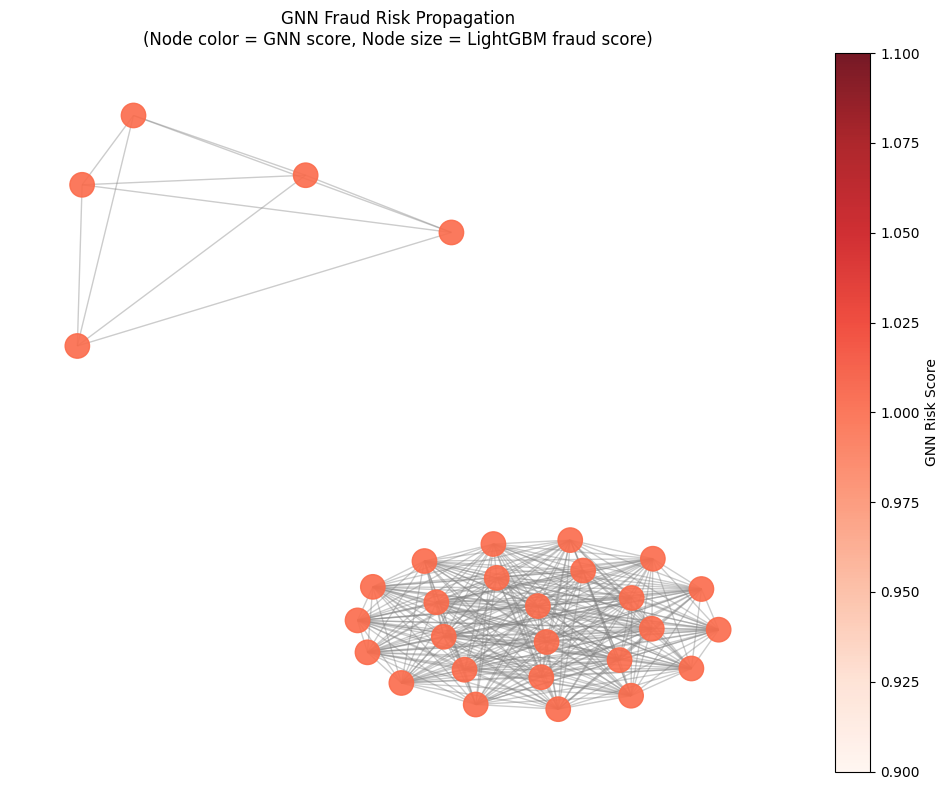

In [23]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# --- Create figure and axis explicitly ---
fig, ax = plt.subplots(figsize=(10, 8))

# Layout
pos = nx.spring_layout(G, seed=42, k=0.8)

# Node aesthetics
node_colors = np.array([G.nodes[n]["gnn_score"] for n in G.nodes()])
node_sizes = np.array([G.nodes[n]["fraud_score"] for n in G.nodes()])

# Scale sizes for visibility
node_sizes = 300 + 8000 * node_sizes

# Draw graph
nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    cmap=plt.cm.Reds,
    ax=ax,
    alpha=0.9
)

nx.draw_networkx_edges(
    G,
    pos,
    edge_color="gray",
    alpha=0.4,
    ax=ax
)

# --- Proper colorbar ---
cbar = fig.colorbar(nodes, ax=ax)
cbar.set_label("GNN Risk Score")

ax.set_title(
    "GNN Fraud Risk Propagation\n"
    "(Node color = GNN score, Node size = LightGBM fraud score)",
    fontsize=12
)

ax.axis("off")
plt.tight_layout()
plt.show()

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from mpl_toolkits.mplot3d import Axes3D

In [25]:
# 3D spring layout
pos_3d = nx.spring_layout(G, dim=3, seed=42)

In [26]:
nodes = list(G.nodes())

x_vals = np.array([pos_3d[n][0] for n in nodes])
y_vals = np.array([pos_3d[n][1] for n in nodes])
z_vals = np.array([pos_3d[n][2] for n in nodes])

gnn_scores = np.array([G.nodes[n]["gnn_score"] for n in nodes])
fraud_scores = np.array([G.nodes[n]["fraud_score"] for n in nodes])

# Scale node sizes for visibility
node_sizes = 300 + 8000 * fraud_scores

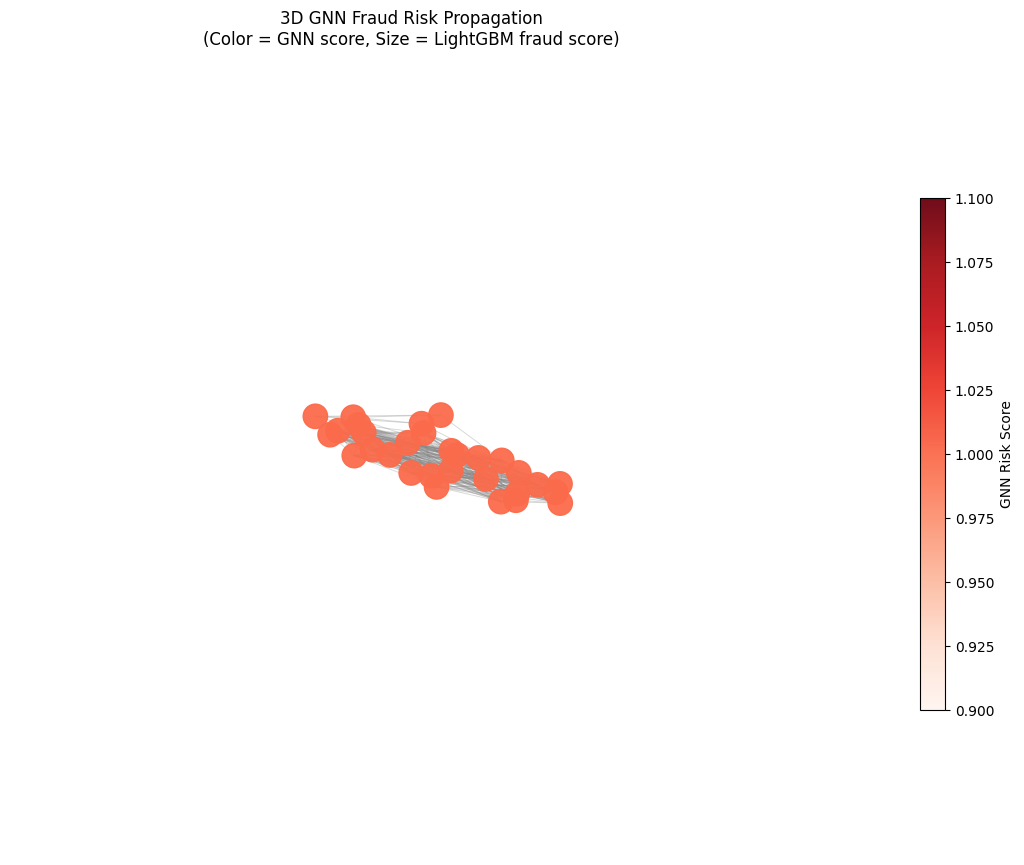

In [27]:
fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection="3d")

# ---- Draw edges ----
for u, v in G.edges():
    xs = [pos_3d[u][0], pos_3d[v][0]]
    ys = [pos_3d[u][1], pos_3d[v][1]]
    zs = [pos_3d[u][2], pos_3d[v][2]]
    ax.plot(xs, ys, zs, color="gray", alpha=0.3, linewidth=0.7)

# ---- Draw nodes ----
sc = ax.scatter(
    x_vals,
    y_vals,
    z_vals,
    c=gnn_scores,
    s=node_sizes,
    cmap="Reds",
    alpha=0.95
)

# ---- Colorbar ----
cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label("GNN Risk Score")

# ---- Titles & labels ----
ax.set_title(
    "3D GNN Fraud Risk Propagation\n"
    "(Color = GNN score, Size = LightGBM fraud score)",
    fontsize=12
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [28]:
 import plotly.graph_objects as go
import numpy as np

# Node positions
x = x_vals
y = y_vals
z = z_vals

# Edge coordinates
edge_x, edge_y, edge_z = [], [], []

for u, v in G.edges():
    edge_x += [pos_3d[u][0], pos_3d[v][0], None]
    edge_y += [pos_3d[u][1], pos_3d[v][1], None]
    edge_z += [pos_3d[u][2], pos_3d[v][2], None]

edge_trace = go.Scatter3d(
    x=edge_x,
    y=edge_y,
    z=edge_z,
    mode="lines",
    line=dict(color="gray", width=2),
    hoverinfo="none"
)

node_trace = go.Scatter3d(
    x=x,
    y=y,
    z=z,
    mode="markers",
    marker=dict(
        size=8 + 40 * fraud_scores,
        color=gnn_scores,
        colorscale="Reds",
        colorbar=dict(title="GNN Risk Score"),
        opacity=0.9
    ),
    text=[
        f"Tx {n}<br>Fraud score: {G.nodes[n]['fraud_score']:.4f}<br>GNN score: {G.nodes[n]['gnn_score']:.4f}"
        for n in nodes
    ],
    hoverinfo="text"
)

fig = go.Figure(data=[edge_trace, node_trace])
fig.update_layout(
    title="Interactive 3D GNN Fraud Risk Propagation",
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False)
    ),
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()